### Importación, Configuración y Carga del Pipeline

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Configurar tema de Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Continuamos el pipeline cargando los datos del JSON de MongoDB
ruta_json = '../data/mongo_export.json'
with open(ruta_json, 'r') as archivo:
    datos = json.load(archivo)

# Aplanamos el JSON a un DataFrame de Pandas
df = pd.json_normalize(datos)

# Limpieza rápida para visualización (renombramos columnas largas)
df.rename(columns={
    'hotel.type': 'hotel_type',
    'booking_info.adr': 'adr',
    'booking_info.lead_time': 'lead_time',
    'booking_info.status': 'status',
    'booking_info.guests.adults': 'adults'
}, inplace=True)

print(f"Datos cargados para visualización: {df.shape[0]} filas.")
df.head(3)

Datos cargados para visualización: 119390 filas.


,_id,reservation_sql_id,tags,hotel_type,customer.type,customer.country,lead_time,adr,status,adults,booking_info.guests.children,booking_info.guests.babies,booking_info.vip_status
0,69eb7e99b32fa04ea569e9ee,1,[],Resort Hotel,Generic Customer,Unknown,342,0.0,Active,2,0,0,NaN
1,69eb7e99b32fa04ea569e9ef,2,[],Resort Hotel,Generic Customer,Unknown,737,0.0,Active,2,0,0,NaN
2,69eb7e99b32fa04ea569e9f0,3,[],Resort Hotel,Generic Customer,Unknown,7,75.0,Active,1,0,0,NaN


### Análisis Individual - Matplotlib (Línea, Torta y Dispersión)

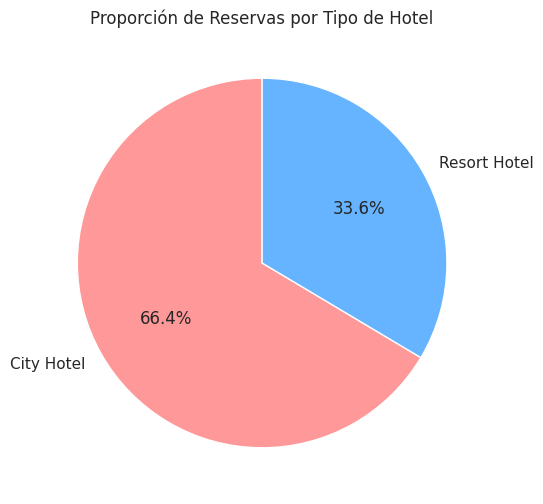

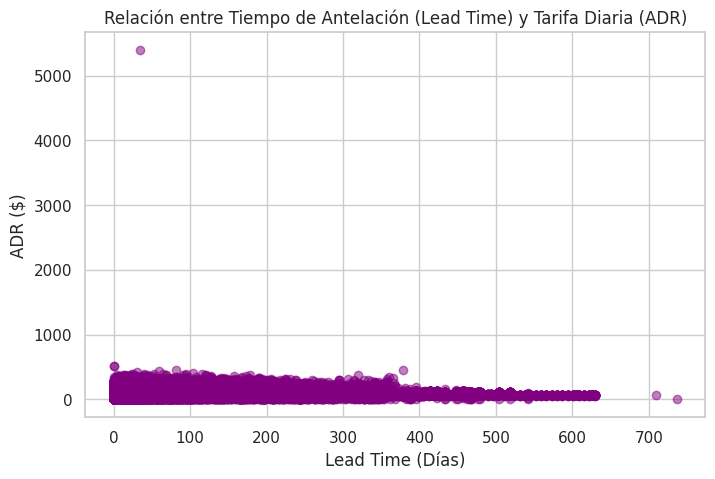

In [4]:
# 1. Gráfico de Torta: Proporción de Tipos de Hotel
fig, ax = plt.subplots(figsize=(6, 6)) # Requisito: fig, ax
hotel_counts = df['hotel_type'].value_counts()
ax.pie(hotel_counts, labels=hotel_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
ax.set_title('Proporción de Reservas por Tipo de Hotel')
plt.savefig('../reports/pie_hoteles.png', dpi=300) #Exportar imagen
plt.show()

# 2. Gráfico de Dispersión (Scatter): Lead Time vs ADR
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['lead_time'], df['adr'], alpha=0.5, color='purple')
ax.set_title('Relación entre Tiempo de Antelación (Lead Time) y Tarifa Diaria (ADR)')
ax.set_xlabel('Lead Time (Días)')
ax.set_ylabel('ADR ($)')
plt.savefig('../reports/scatter_lead_adr.png', dpi=300)
plt.show()

### Análisis Individual - Seaborn (Heatmap y Correlación)

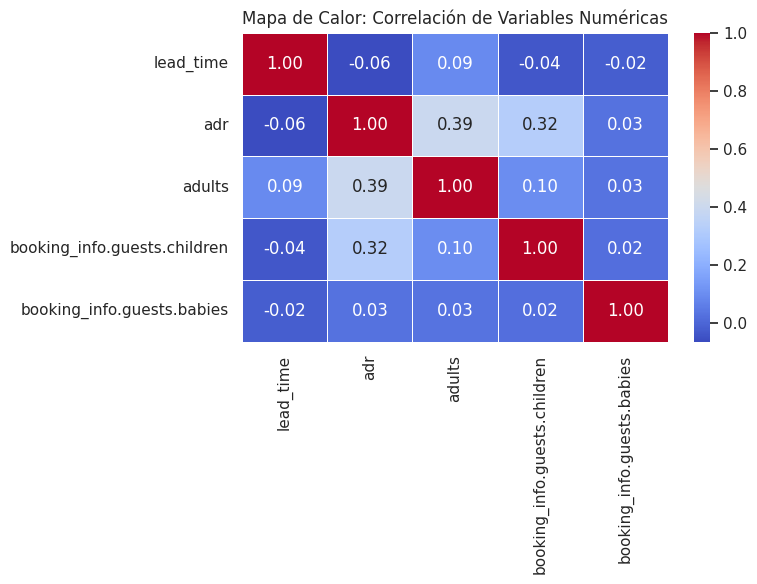

In [5]:
# Filtramos solo columnas numéricas para la correlación
cols_numericas = ['lead_time', 'adr', 'adults', 'booking_info.guests.children', 'booking_info.guests.babies']
matriz_corr = df[cols_numericas].corr()

plt.figure(figsize=(8, 6))
# Requisito: heatmap
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor: Correlación de Variables Numéricas')
plt.tight_layout()
plt.savefig('../reports/heatmap_correlacion.png', dpi=300)
plt.show()

### Dashboard Integrado 

/tmp/ipykernel_26742/3950218380.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status', y='lead_time', palette='Set2', ax=axes[1, 0])


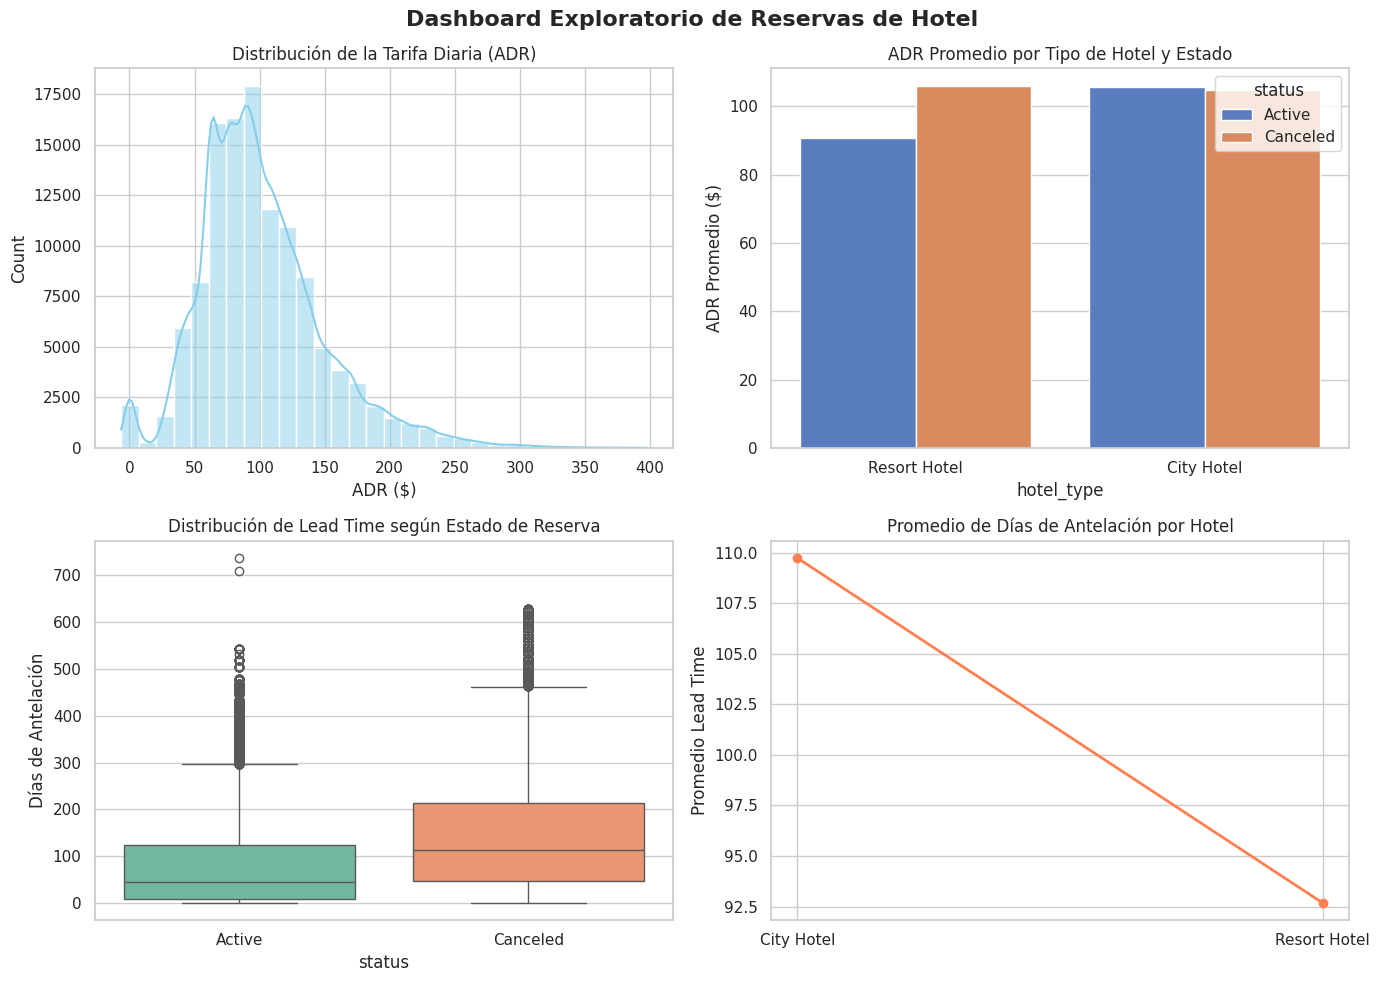

In [6]:
# Requisito: fig, ax = plt.subplots(2, 2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Título general (Requisito: fig.suptitle)
fig.suptitle('Dashboard Exploratorio de Reservas de Hotel', fontsize=16, fontweight='bold')

# 1. Top Izquierda: Histograma (Seaborn histplot) - Distribución del ADR
sns.histplot(data=df[df['adr'] < 400], x='adr', bins=30, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribución de la Tarifa Diaria (ADR)')
axes[0, 0].set_xlabel('ADR ($)')

# 2. Top Derecha: Gráfico de Barras (Seaborn barplot) - ADR Promedio por Hotel
sns.barplot(data=df, x='hotel_type', y='adr', hue='status', errorbar=None, ax=axes[0, 1])
axes[0, 1].set_title('ADR Promedio por Tipo de Hotel y Estado')
axes[0, 1].set_ylabel('ADR Promedio ($)')

# 3. Bottom Izquierda: Boxplot (Seaborn boxplot) - Outliers de Lead Time
sns.boxplot(data=df, x='status', y='lead_time', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Distribución de Lead Time según Estado de Reserva')
axes[1, 0].set_ylabel('Días de Antelación')

# 4. Bottom Derecha: Gráfico de Línea (Matplotlib) - Tendencia de Lead Time
tendencia = df.groupby('hotel_type')['lead_time'].mean()
axes[1, 1].plot(tendencia.index, tendencia.values, marker='o', linestyle='-', color='coral', linewidth=2)
axes[1, 1].set_title('Promedio de Días de Antelación por Hotel')
axes[1, 1].set_ylabel('Promedio Lead Time')

# Ajustar layout y guardar alta resolución (Requisito: tight_layout y savefig)
plt.tight_layout()
plt.savefig('../reports/dashboard_completo.png', dpi=300)
plt.show()